# Bathymetry Smoothing

In sigma-coordinate ocean models such as FVCOM, sharp changes in bathymetry
between adjacent elements can introduce spurious pressure gradient errors.
The severity of this effect is quantified by the **Haney r-factor**:

$$r = \frac{|h_i - h_j|}{h_i + h_j}$$

where $h_i$ and $h_j$ are the mean depths of two adjacent elements.
Values of $r > 0.2$ are commonly associated with significant pressure gradient
errors. FVCOM is generally less sensitive to this than finite-difference
sigma-coordinate models, but pre-smoothing the bathymetry in regions with
steep gradients is good practice.

PyFVCOM2 provides the `GlobalBathymetrySmoother`, which applies one or more
passes of a node→centroid→node ping-pong interpolation across the entire mesh.
Each pass is equivalent to a single Laplacian smoothing step and reduces
sharp depth gradients uniformly.

> **Cold-start only.** Smoothing changes the physical depth at every sigma
> level. Applying it after generating a restart file would produce an
> internally inconsistent hot start. Always smooth before generating forcing
> or restart files.

## What this notebook covers

1. Load the Tamar estuary grid and visualise the mesh
2. Compute the r-factor distribution on the raw bathymetry
3. Apply the `GlobalBathymetrySmoother` and compare
4. Write the smoothed grid to file


## 1. Imports and setup


In [1]:
import copy
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

from pyfvcom2.grid import create_grid
from pyfvcom2.bathy_smoother import GlobalBathymetrySmoother


/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [2]:
data_dir = os.path.expanduser('~/data/pyfvcom2_doc/FVCOM_tamar_estuary')

grid_file  = f'{data_dir}/tamar_v2_grd.dat'
obc_file   = f'{data_dir}/tamar_v2_obc.dat'
sigma_file = f'{data_dir}/sigma_gen.dat'

print(f'Grid:  {grid_file}')
print(f'OBC:   {obc_file}')
print(f'Sigma: {sigma_file}')

Grid:  /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/tamar_v2_grd.dat
OBC:   /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/tamar_v2_obc.dat
Sigma: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/sigma_gen.dat


## 2. Load the grid and visualise the mesh


In [3]:
grid = create_grid(
    grid_file=grid_file,
    mesh_type='fvcom',
    sigma_file=sigma_file,
    coordinate_system='cartesian',
    obc_filename=obc_file,
    epsg_code='32630',
)

print(f'Nodes:    {grid.n_nodes:,}')
print(f'Elements: {grid.n_elements:,}')
print(f'Depth range: {grid.bathy_nodes.min():.1f} – {grid.bathy_nodes.max():.1f} m')

Nodes:    39,910
Elements: 75,400
Depth range: -6.6 – 80.3 m


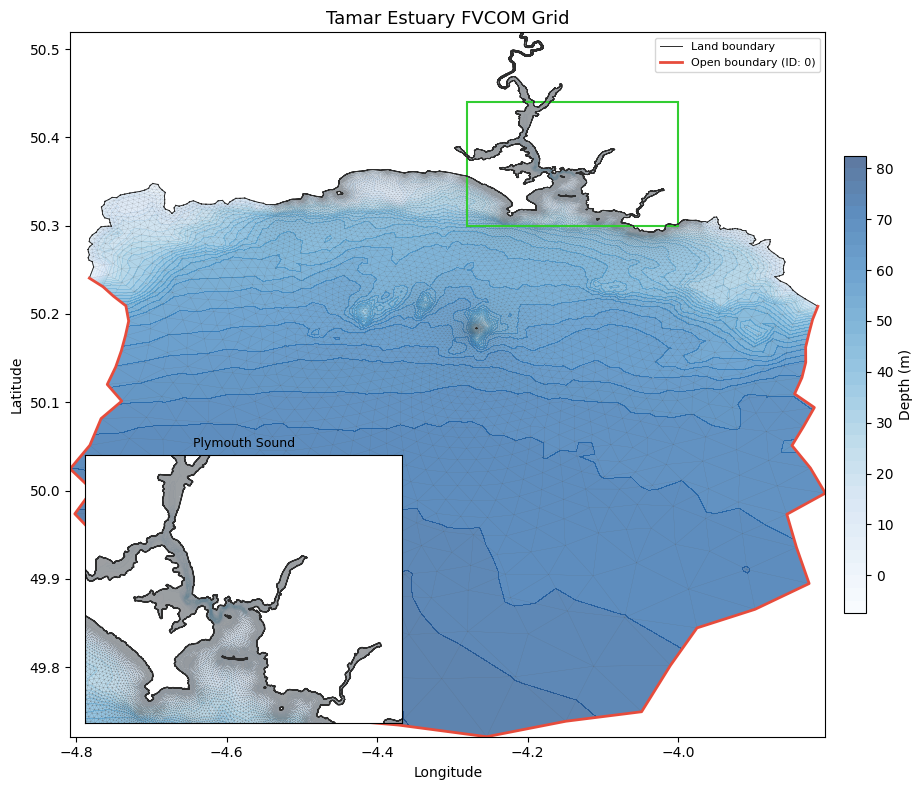

Open boundaries: 1
  OB 0 has 45 nodes
Land boundary edges: 4,388


In [4]:

# ── Identify exterior boundary edges ──────────────────────────────────────
# An edge is a boundary edge if it belongs to exactly one element.
tris = grid.triangles
all_edges = np.vstack([
    np.column_stack([np.minimum(tris[:, 0], tris[:, 1]),
                     np.maximum(tris[:, 0], tris[:, 1])]),
    np.column_stack([np.minimum(tris[:, 1], tris[:, 2]),
                     np.maximum(tris[:, 1], tris[:, 2])]),
    np.column_stack([np.minimum(tris[:, 2], tris[:, 0]),
                     np.maximum(tris[:, 2], tris[:, 0])]),
])
unique_edges, counts = np.unique(all_edges, axis=0, return_counts=True)
bdy_edges = unique_edges[counts == 1]           # shape (n_bdy_edges, 2)

# Classify boundary edges as open-boundary or land
obc_node_arr = np.concatenate([obc.node_indices for obc in grid.open_boundaries])
is_obc_edge = np.isin(bdy_edges[:, 0], obc_node_arr) & np.isin(bdy_edges[:, 1], obc_node_arr)
land_edges = bdy_edges[~is_obc_edge]

# Efficient nan-separated arrays for plotting (one plot() call per segment type)
def _edge_lines(edges, lon, lat):
    out_x = np.empty(len(edges) * 3); out_x[2::3] = np.nan
    out_y = np.empty(len(edges) * 3); out_y[2::3] = np.nan
    out_x[0::3] = lon[edges[:, 0]]; out_x[1::3] = lon[edges[:, 1]]
    out_y[0::3] = lat[edges[:, 0]]; out_y[1::3] = lat[edges[:, 1]]
    return out_x, out_y

land_x, land_y = _edge_lines(land_edges, grid.lon_nodes, grid.lat_nodes)

# ── Figure layout ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

triang_geo = mtri.Triangulation(grid.lon_nodes, grid.lat_nodes, grid.triangles)

# Shaded bathymetry (alpha keeps grid lines visible through the fill)
tcf = ax.tricontourf(triang_geo, grid.bathy_nodes, levels=40, cmap='Blues', alpha=0.65)
fig.colorbar(tcf, ax=ax, label='Depth (m)', shrink=0.65, pad=0.02)

# Mesh grid lines
ax.triplot(triang_geo, color='0.35', linewidth=0.12, alpha=0.55)

# Land boundary
ax.plot(land_x, land_y, '-', color='#2d2d2d', linewidth=0.7, label='Land boundary')

# Open boundary segments (one colour per section)
obc_palette = ['#e74c3c', '#e67e22', '#8e44ad']
for i, obc in enumerate(grid.open_boundaries):
    ni = obc.node_indices
    col = obc_palette[i % len(obc_palette)]
    ax.plot(grid.lon_nodes[ni], grid.lat_nodes[ni], '-', color=col, linewidth=2.0,
            label=f'Open boundary (ID: {obc.bdy_id})')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Tamar Estuary FVCOM Grid', fontsize=13)
ax.legend(loc='upper right', fontsize=8, framealpha=0.8)

# ── Plymouth Sound inset ──────────────────────────────────────────────────
# Approximate bounding box for Plymouth Sound / lower Tamar estuary
ps_lon = (-4.28, -4.00)
ps_lat = (50.30, 50.44)

ax_ins = ax.inset_axes([0.02, 0.02, 0.42, 0.38])

ax_ins.tricontourf(triang_geo, grid.bathy_nodes, levels=40, cmap='Blues', alpha=0.65)
ax_ins.triplot(triang_geo, color='0.35', linewidth=0.2, alpha=0.55)
ax_ins.plot(land_x, land_y, '-', color='#2d2d2d', linewidth=0.9)
for i, obc in enumerate(grid.open_boundaries):
    ni = obc.node_indices
    ax_ins.plot(grid.lon_nodes[ni], grid.lat_nodes[ni], '-',
                color=obc_palette[i % len(obc_palette)], linewidth=2.0)

ax_ins.set_xlim(*ps_lon)
ax_ins.set_ylim(*ps_lat)
ax_ins.set_xticks([])
ax_ins.set_yticks([])
ax_ins.set_title('Plymouth Sound', fontsize=9)
ax_ins.tick_params(labelsize=7)

# Rectangle on main plot showing the inset extent
rect = Rectangle((ps_lon[0], ps_lat[0]),
                 ps_lon[1] - ps_lon[0], ps_lat[1] - ps_lat[0],
                 linewidth=1.5, edgecolor='limegreen', facecolor='none')
ax.add_patch(rect)

plt.tight_layout()
plt.show()

print(f'Open boundaries: {grid.n_open_boundaries}')
for obc in grid.open_boundaries:
    print(f'  OB {obc.bdy_id} has {obc.nnodes} nodes')
print(f'Land boundary edges: {len(land_edges):,}')


## 3. R-factor distribution on the raw bathymetry

The `GlobalBathymetrySmoother` exposes an `r_factor()` method that computes
the Haney r-factor for every inter-element edge without modifying the grid.
We use this as a diagnostic on the original bathymetry before any smoothing.


In [5]:
smoother = GlobalBathymetrySmoother(passes=3)

r_raw = smoother.r_factor(grid)

n_total   = len(r_raw)
n_wet     = int((~np.isnan(r_raw)).sum())
n_masked  = n_total - n_wet

print(f'Depth range: {grid.bathy_nodes.min():.2f} to {grid.bathy_nodes.max():.1f} m')
print()
print(f'Total inter-element edges:  {n_total:,}')
print(f'  Submerged (evaluated):    {n_wet:,}')
print(f'  Intertidal (masked):      {n_masked:,}')
print()
print(f'Max r-factor:       {np.nanmax(r_raw):.4f}')
print(f'Mean r-factor:      {np.nanmean(r_raw):.4f}')
n_bad = int((r_raw > 0.2).sum())
print(f'Edges with r > 0.2: {n_bad:,} ({100*n_bad/n_wet:.1f}% of submerged edges)')

Depth range: -6.56 to 80.3 m

Total inter-element edges:  110,884
  Submerged (evaluated):    94,617
  Intertidal (masked):      16,267

Max r-factor:       1.0000
Mean r-factor:      0.0618
Edges with r > 0.2: 7,053 (7.5% of submerged edges)


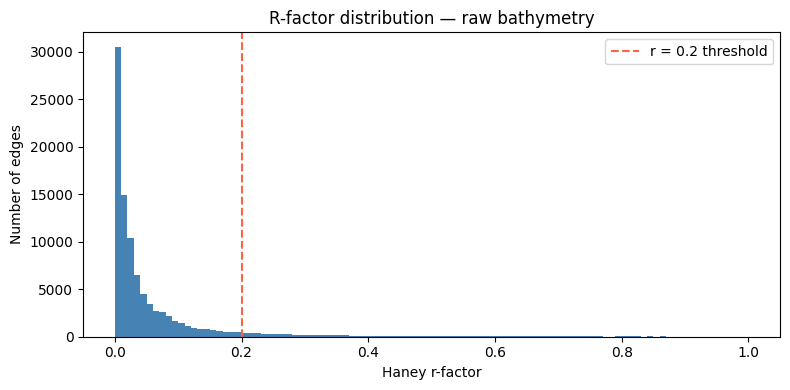

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(r_raw, bins=100, color='steelblue', edgecolor='none')
ax.axvline(0.2, color='tomato', linestyle='--', label='r = 0.2 threshold')
ax.set_xlabel('Haney r-factor')
ax.set_ylabel('Number of edges')
ax.set_title('R-factor distribution — raw bathymetry')
ax.legend()
plt.tight_layout()
plt.show()

Edges violating r > 0.2: 7,053 of 94,617 submerged edges (7.5%)
Worst edge: r = 1.0000  at (-4.2300°, 50.3905°)


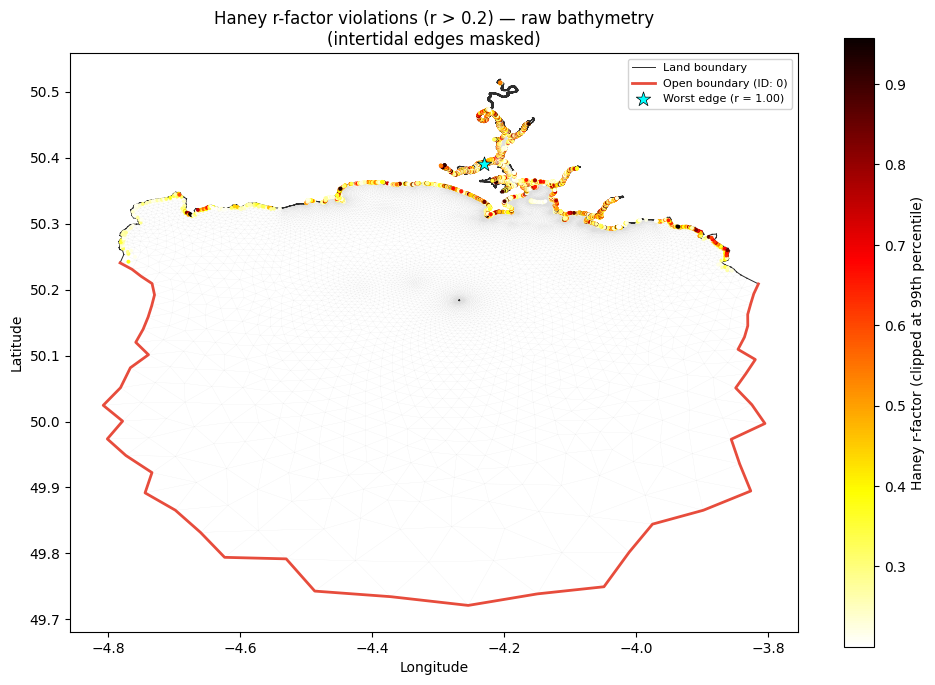

In [7]:
# ── Shared-edge midpoints in geographic coordinates ─────────────────────
# Reuses triang_geo, land_x/y, obc_palette from the mesh visualisation cell.
h_nodes = grid.bathy_nodes
triangles = grid.triangles

edge_to_elem: dict = {}
edge_node_pairs: list = []

for ei, tri in enumerate(triangles):
    for a, b in ((tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])):
        key = frozenset((int(a), int(b)))
        if key in edge_to_elem:
            edge_node_pairs.append((int(a), int(b)))
        else:
            edge_to_elem[key] = ei

edge_node_pairs = np.array(edge_node_pairs, dtype=np.intp)
edge_mlon = (grid.lon_nodes[edge_node_pairs[:, 0]] + grid.lon_nodes[edge_node_pairs[:, 1]]) / 2
edge_mlat = (grid.lat_nodes[edge_node_pairs[:, 0]] + grid.lat_nodes[edge_node_pairs[:, 1]]) / 2

r_thresh  = 0.2
bad       = r_raw > r_thresh          # NaN comparisons are False — intertidal edges excluded
worst_idx = int(np.nanargmax(r_raw))  # index of the worst submerged edge
n_wet_edges = int((~np.isnan(r_raw)).sum())

print(f'Edges violating r > {r_thresh}: {bad.sum():,} of {n_wet_edges:,} '
      f'submerged edges ({100*bad.sum()/n_wet_edges:.1f}%)')
print(f'Worst edge: r = {r_raw[worst_idx]:.4f}  '
      f'at ({edge_mlon[worst_idx]:.4f}°, {edge_mlat[worst_idx]:.4f}°)')

fig, ax = plt.subplots(figsize=(10, 9))

# Mesh (very light so coloured boundaries and scatter stand out)
ax.triplot(triang_geo, color='0.82', linewidth=0.10, alpha=0.7, zorder=1)

# Land boundary
ax.plot(land_x, land_y, '-', color='#2d2d2d', linewidth=0.7, zorder=2,
        label='Land boundary')

# Open boundary sections
for i, obc in enumerate(grid.open_boundaries):
    ni = obc.node_indices
    col = obc_palette[i % len(obc_palette)]
    ax.plot(grid.lon_nodes[ni], grid.lat_nodes[ni], '-', color=col,
            linewidth=2.0, zorder=3, label=f'Open boundary (ID: {obc.bdy_id})')

# Violating edges: scatter coloured by r-factor, clipped at 99th percentile
r_bad  = r_raw[bad]
r_plot = np.clip(r_bad, 0, np.percentile(r_bad, 99) if r_bad.size else 1)
sc = ax.scatter(edge_mlon[bad], edge_mlat[bad], s=8, c=r_plot,
                cmap='hot_r', linewidths=0, zorder=4)
plt.colorbar(sc, ax=ax, label='Haney r-factor (clipped at 99th percentile)', shrink=0.7)

# Worst edge
ax.scatter(edge_mlon[worst_idx], edge_mlat[worst_idx], s=120, marker='*',
           c='cyan', edgecolors='black', linewidths=0.5, zorder=5,
           label=f'Worst edge (r = {r_raw[worst_idx]:.2f})')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Haney r-factor violations (r > {r_thresh}) — raw bathymetry\n'
             f'(intertidal edges masked)')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8, framealpha=0.85)
plt.tight_layout()
plt.show()

In [8]:
# ── Diagnose the worst-r edge ──────────────────────────────────────────────
# Rebuild edge → (elem_a, elem_b) mapping so we can inspect both elements.
_edge_to_elem: dict = {}
_edge_node_pairs: list = []
_edge_elem_pairs: list = []

for ei, tri in enumerate(triangles):
    for a, b in ((tri[0], tri[1]), (tri[1], tri[2]), (tri[2], tri[0])):
        key = frozenset((int(a), int(b)))
        if key in _edge_to_elem:
            _edge_node_pairs.append((int(a), int(b)))
            _edge_elem_pairs.append((_edge_to_elem[key], ei))
        else:
            _edge_to_elem[key] = ei

_edge_node_pairs = np.array(_edge_node_pairs, dtype=np.intp)
_edge_elem_pairs = np.array(_edge_elem_pairs, dtype=np.intp)

# Recompute element-mean depths
h_elems = h_nodes[triangles].mean(axis=1)

worst = int(np.nanargmax(r_raw))
ea, eb = _edge_elem_pairs[worst]
na, nb = _edge_node_pairs[worst]   # the two nodes on the shared edge

hi = h_elems[ea]
hj = h_elems[eb]

print("=" * 55)
print(f"Worst edge index : {worst}")
print(f"Shared nodes     : {na}, {nb}")
print(f"Edge midpoint    : ({edge_mlon[worst]:.4f}°, {edge_mlat[worst]:.4f}°)")
print()
print(f"Element A  (index {ea})")
print(f"  Node indices : {triangles[ea]}")
print(f"  Node depths  : {h_nodes[triangles[ea]]}")
print(f"  Element mean : {hi:.6f} m")
print()
print(f"Element B  (index {eb})")
print(f"  Node indices : {triangles[eb]}")
print(f"  Node depths  : {h_nodes[triangles[eb]]}")
print(f"  Element mean : {hj:.6f} m")
print()
print(f"h_A + h_B        : {hi + hj:.6f} m  ← denominator")
print(f"|h_A - h_B|      : {abs(hi - hj):.6f}")
print(f"r-factor         : {r_raw[worst]:.4f}")

Worst edge index : 88457
Shared nodes     : 31414, 31392
Edge midpoint    : (-4.2300°, 50.3905°)

Element A  (index 59938)
  Node indices : [31392 31414 31391]
  Node depths  : [ 1.894078 -0.663503 -1.230446]
  Element mean : 0.000043 m

Element B  (index 59939)
  Node indices : [31414 31392 31393]
  Node depths  : [-0.663503  1.894078  4.09161 ]
  Element mean : 1.774062 m

h_A + h_B        : 1.774105 m  ← denominator
|h_A - h_B|      : 1.774019
r-factor         : 1.0000


## 4. Apply the Global smoother

The `GlobalBathymetrySmoother` applies a node→centroid→node interpolation
pass across the entire mesh. Each pass is equivalent to one step of
graph-Laplacian smoothing, gently reducing sharp depth gradients throughout
the domain. Increasing `passes` produces stronger smoothing but progressively
erodes bathymetric features — choose the minimum needed to satisfy the
r-factor criterion in your area of interest.

In [9]:
grid_smooth = copy.deepcopy(grid)

smoother.smooth(grid_smooth)

r_smooth = smoother.r_factor(grid_smooth)

print(f'After {smoother._passes} passes of global smoothing:')
print(f'  Max r-factor:       {r_smooth.max():.4f}')
print(f'  Mean r-factor:      {r_smooth.mean():.4f}')
print(f'  Edges with r > 0.2: {(r_smooth > 0.2).sum():,}')
print()
dh = grid_smooth.bathy_nodes - grid.bathy_nodes
print(f'Depth change at nodes:')
print(f'  Max absolute change: {np.abs(dh).max():.3f} m')
print(f'  Nodes modified:      {(np.abs(dh) > 1e-10).sum():,} of {grid.n_nodes:,}')

After 3 passes of global smoothing:
  Max r-factor:       nan
  Mean r-factor:      nan
  Edges with r > 0.2: 5,380

Depth change at nodes:
  Max absolute change: 17.829 m
  Nodes modified:      39,839 of 39,910


## 5. Comparison plots

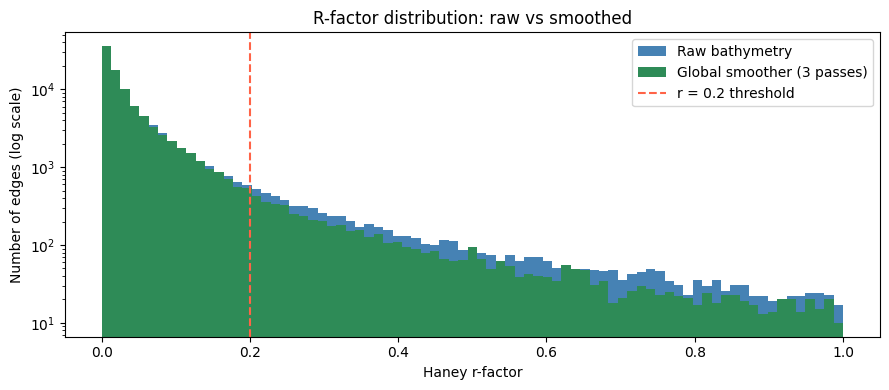

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

bins = np.linspace(0, max(np.nanmax(r_raw), np.nanmax(r_smooth)), 80)

ax.hist(r_raw,    bins=bins, label='Raw bathymetry',                        color='steelblue',  log=True)
ax.hist(r_smooth, bins=bins, label=f'Global smoother ({smoother._passes} passes)', color='seagreen',   log=True)
ax.axvline(0.2, color='tomato', linestyle='--', linewidth=1.5, label='r = 0.2 threshold')
ax.set_xlabel('Haney r-factor')
ax.set_ylabel('Number of edges (log scale)')
ax.set_title('R-factor distribution: raw vs smoothed')
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
triang = mtri.Triangulation(grid.lon_nodes, grid.lat_nodes, grid.triangles)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True,
                         constrained_layout=True)

vmin = min(grid.bathy_nodes.min(), grid_smooth.bathy_nodes.min())
vmax = max(grid.bathy_nodes.max(), grid_smooth.bathy_nodes.max())

for ax, g, title in zip(
    axes,
    [grid, grid_smooth],
    ['Raw bathymetry', f'Global smoother ({smoother._passes} passes)'],
):
    tcf = ax.tricontourf(triang, g.bathy_nodes, levels=50, vmin=vmin, vmax=vmax, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_aspect('equal')

axes[0].set_ylabel('Latitude')
fig.colorbar(tcf, ax=axes.tolist(), label='Depth (m)', shrink=0.85)
fig.suptitle('Tamar estuary bathymetry')
plt.show()

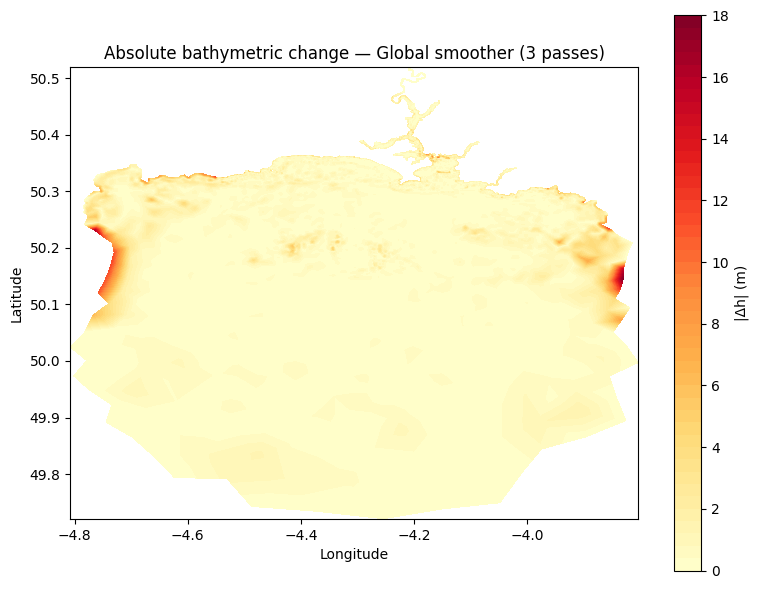

In [12]:
dh_abs = np.abs(grid_smooth.bathy_nodes - grid.bathy_nodes)

fig, ax = plt.subplots(figsize=(8, 6))

tcf = ax.tricontourf(triang, dh_abs, levels=50, vmin=0, cmap='YlOrRd')
ax.set_title(f'Absolute bathymetric change — Global smoother ({smoother._passes} passes)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
fig.colorbar(tcf, ax=ax, label='|Δh| (m)')
plt.tight_layout()
plt.show()

## 6. Write the smoothed grid

Once satisfied with the smoothing, write the modified grid to file.
This produces the `.dat` files consumed by FVCOM's `GRID_FILE` and
`DEPTH_FILE` namelist entries.

In [13]:
out_dir = os.path.join(data_dir, 'smoothed_inputs')
os.makedirs(out_dir, exist_ok=True)

out_grid  = os.path.join(out_dir, 'tamar_v2_smooth_grd.dat')
out_depth = os.path.join(out_dir, 'tamar_v2_smooth_dep.dat')

grid_smooth.write_grid(
    grid_file=out_grid,
    coordinate_system='geographic',
    depth_file=out_depth,
)

print(f'Smoothed grid written to:  {out_grid}')
print(f'Smoothed depth written to: {out_depth}')

Smoothed grid written to:  /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/smoothed_inputs/tamar_v2_smooth_grd.dat
Smoothed depth written to: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/smoothed_inputs/tamar_v2_smooth_dep.dat
